## Introduction

This project allocates capital across 14 stocks using a rolling mean-variance optimization with Ledoit-Wolf covariance shrinkage. Instead of putting equal money into every stock, it weights each one by its recent risk-adjusted performance and its correlation with the others. The question is whether that added complexity actually beats an equal-weight portfolio, or just fits noise.

## 1. Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from sklearn.covariance import LedoitWolf
warnings.filterwarnings('ignore')

## 2. Configuration

All parameters defined in one place.

The portfolio spans six sectors on purpose: technology (Apple, Google, Microsoft), clean energy (NextEra, Constellation), healthcare (AbbVie, UnitedHealth, Eli Lilly), commodities (silver and copper ETFs, plus Freeport-McMoRan, a copper and gold miner), fixed income (Treasury bond ETFs at two different durations), and financials (Visa). Holding genuinely different asset types matters because when one sector falls, others often hold up. That is the foundation of diversification, and it's the main reason both strategies here beat SPY.

In [2]:
#Asset universe
PORTFOLIO = [
    #Tech (stable variance estimates)
    'AAPL', 'GOOGL', 'MSFT',

    #Clean energy (liquid, non-distressed)
    'NEE', 'CEG',

    #Healthcare (defensive, moderate risk)
    'ABBV', 'UNH', 'LLY',

    #Commodities (genuine diversifiers)
    'SLV', 'CPER', 'FCX',

    #Fixed income (risk-off, negative equity correlation)
    'TLT', 'IEF',

    # Financials
    'V',
]
BENCHMARK = 'SPY'

#Date range
START = '2024-12-01'
END   = '2025-12-01'

#Annualization: US market hours only (~6.5 hrs/day x 252 days)
HOURS_PER_YEAR = int(252 * 6.5)  # 1638

#Risk-free rate
RF_YEAR = 2.90 / 100
RF_HOUR = (1 + RF_YEAR) ** (1 / HOURS_PER_YEAR) - 1

#Rolling window length (hours)
M = 504  # ~3 weeks of trading hours

#Per-asset weight cap (half-Kelly)
KELLY_CAP = 0.15

#Transaction cost (one-way, in decimal)
TC_BPS = 10 / 10_000  # 10 basis points

#Rebalance frequency (hours) — weekly
REBAL_FREQ = 168

print(f'Annual RF        : {RF_YEAR:.2%}')
print(f'Hourly RF        : {RF_HOUR:.3e}')
print(f'Window M         : {M} hours')
print(f'Rebal frequency  : {REBAL_FREQ} hours (weekly)')
print(f'Hours per year   : {HOURS_PER_YEAR}')
print(f'Assets           : {len(PORTFOLIO)}')

Annual RF        : 2.90%
Hourly RF        : 1.745e-05
Window M         : 504 hours
Rebal frequency  : 168 hours (weekly)
Hours per year   : 1638
Assets           : 14


## How the strategy works

Every week the model looks at the past three weeks of hourly price movements and asks which stocks have delivered the best returns relative to their risk, and how correlated they are with each other. It then sets portfolio weights to maximize return per unit of risk, staying fully invested. Individual positions are capped at 15% to limit concentration, and a transaction cost is charged on turnover at each rebalance.

## Why this is better than equal weight

Equal weight holds the same amount of every stock, rebalancing back to equal periodically. It's a strong benchmark, partly because rebalancing is mechanically contraria, it trims what has risen and adds to what has fallen and because it requires no estimation at all. Every parameter an optimizer estimates is a parameter it can get wrong.

The optimized strategy tries to do better by weighting stocks deliberately, based on their recent risk-adjusted returns and correlations. The question this project tests is whether that deliberation adds value out of sample, or whether the extra estimation just fits noise.

## 3. Data Download

In [3]:
CACHE = 'prices_hourly.parquet'
TICKERS = PORTFOLIO + [BENCHMARK]

if os.path.exists(CACHE):
    raw = pd.read_parquet(CACHE)
    print(f'Loaded from cache: {CACHE}')
else:
    raw = yf.download(
        TICKERS, start=START, end=END, interval='60m',
        progress=False, auto_adjust=True, threads=False,
    )['Close']

    missing = set(TICKERS) - set(raw.columns)
    assert not missing, f'Failed downloads: {missing}'
    dead = raw.columns[raw.isna().all()].tolist()
    assert not dead, f'All-NaN columns: {dead}'

    raw = raw.ffill().dropna()
    raw.to_parquet(CACHE)
    print(f'Downloaded and cached to {CACHE}')

assert len(raw) > M + 100, f'Only {len(raw)} rows, need > {M}'

prices    = raw[PORTFOLIO]
spy_price = raw[BENCHMARK]

print(f'Price matrix shape: {prices.shape}')
print(f'Range: {raw.index[0]} → {raw.index[-1]}')
display(prices.head())

Downloaded and cached to prices_hourly.parquet
Price matrix shape: (1731, 14)
Range: 2024-12-02 14:30:00+00:00 → 2025-11-28 16:30:00+00:00


Ticker,AAPL,GOOGL,MSFT,NEE,CEG,ABBV,UNH,LLY,SLV,CPER,FCX,TLT,IEF,V
Datetime,,,,,,,,,,,,,,
2024-12-02 14:30:00+00:00,240.270004,171.475006,430.579987,77.309998,252.070007,180.240005,602.390015,799.309998,27.776899,25.730000,43.430000,93.105003,94.580101,315.790009
2024-12-02 15:30:00+00:00,239.830002,170.919998,430.295990,77.589996,253.220001,180.925003,606.190002,798.260010,27.722099,25.780001,42.924999,94.074997,94.970001,314.385010
2024-12-02 16:30:00+00:00,239.830002,171.565002,430.924988,77.440002,254.220001,180.630005,605.510010,797.719971,27.754999,25.715401,42.695000,94.000298,94.934998,314.200012
2024-12-02 17:30:00+00:00,239.440002,171.207703,430.740997,77.485001,251.309998,181.313095,606.780029,797.489990,27.730000,25.799999,42.939999,93.875000,94.855003,315.209991
2024-12-02 18:30:00+00:00,239.330002,171.210007,431.290009,77.320099,251.562500,181.780899,607.099976,797.984985,27.718100,25.770000,43.040001,93.900002,94.889999,316.147491


## 4. Returns & Excess Returns

In [4]:
R_df         = prices.pct_change().dropna()
ExcessRet_df = R_df - RF_HOUR

spy_ret      = spy_price.pct_change().reindex(R_df.index).dropna()
ExcessRet_df = ExcessRet_df.reindex(spy_ret.index)
R_df         = R_df.reindex(spy_ret.index)

R  = ExcessRet_df.to_numpy()  # excess returns — used for weight estimation
Rp = R_df.to_numpy()          # total returns  — used for portfolio P&L
T, N = R.shape

print(f'T={T} periods, N={N} assets')

# Verify hourly return range is sensible
print(f'Max single hourly return : {R_df.max().max():.4f}')
print(f'Min single hourly return : {R_df.min().min():.4f}')

T=1730 periods, N=14 assets
Max single hourly return : 0.2108
Min single hourly return : -0.2044


## 5. Kelly Weight Estimator

For each rolling window the Kelly weight vector is estimated via:

$$f \propto \Sigma^{-1}\,\mu$$

Ledoit-Wolf shrinkage is applied to the covariance matrix to handle near-singularity with limited observations.

In [5]:
def kelly_weights(R_window: np.ndarray, cap: float = KELLY_CAP) -> np.ndarray:
    mu  = R_window.mean(axis=0)
    cov = LedoitWolf().fit(R_window).covariance_

    w_raw = np.linalg.solve(cov, mu)

    # Long-only: assets the optimizer rejects stay at zero
    active = w_raw > 0
    if not active.any():
        return np.ones(N) / N

    w = np.zeros(N)
    w[active] = w_raw[active] / w_raw[active].sum()

    # Cap and redistribute among active names only
    for _ in range(50):
        excess = np.maximum(w - cap, 0).sum()
        if excess < 1e-10:
            break
        w = np.clip(w, 0, cap)
        slack = np.where(active, cap - w, 0.0)
        if slack.sum() <= 0:
            break
        w += excess * slack / slack.sum()

    return w / w.sum()

## 6. Rolling Weight Computation

Rebalances: 8
sum=1.000000  min=0.0000  max=0.1500
active positions: 9 of 14


,Weight
GOOGL,0.1500
LLY,0.1500
AAPL,0.1424
NEE,0.1288
ABBV,0.1132
CPER,0.1019
SLV,0.0850
UNH,0.0842
TLT,0.0445
MSFT,0.0000


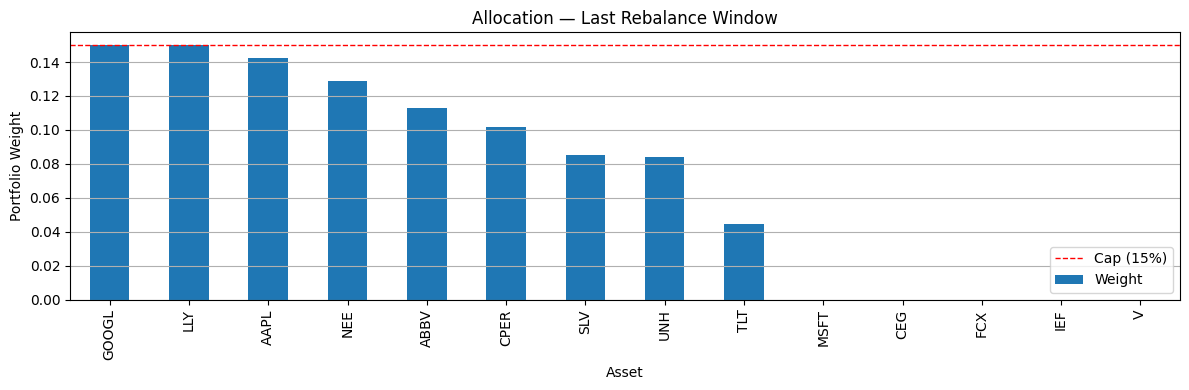

In [6]:
weight_kelly = np.full((T, N), np.nan)

for i in range(0, T - M - 1, REBAL_FREQ):
    w = kelly_weights(R[i:i + M])
    end = min(i + REBAL_FREQ + M + 1, T)
    weight_kelly[i + M + 1:end] = w        # +1 prevents lookahead

weight_ew = np.full((T, N), 1.0 / N)
weight_ew[:M] = np.nan

print(f'Rebalances: {len(range(0, T - M - 1, REBAL_FREQ))}')

last_valid = np.where(~np.isnan(weight_kelly[:, 0]))[0][-1]
last_w = weight_kelly[last_valid]
print(f'sum={last_w.sum():.6f}  min={last_w.min():.4f}  max={last_w.max():.4f}')
print(f'active positions: {(last_w > 1e-6).sum()} of {N}')

kelly_series = pd.Series(last_w, index=PORTFOLIO, name='Weight').sort_values(ascending=False)
display(kelly_series.to_frame().style.format('{:.4f}'))

plt.figure(figsize=(12, 4))
kelly_series.plot(kind='bar')
plt.axhline(KELLY_CAP, color='red', linestyle='--', linewidth=1, label=f'Cap ({KELLY_CAP:.0%})')
plt.title('Allocation — Last Rebalance Window')
plt.ylabel('Portfolio Weight'); plt.xlabel('Asset')
plt.legend(); plt.grid(axis='y'); plt.tight_layout(); plt.show()

## 7. Portfolio Returns

time_index      : 1225
kelly_cumulative: 1225
ew_cumulative   : 1225
spy_cumulative  : 1225


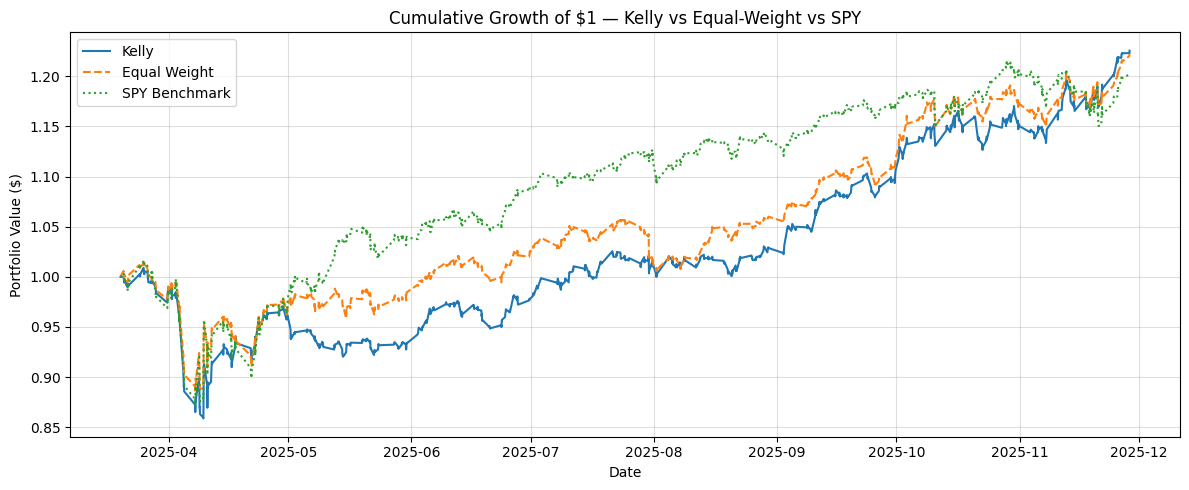

In [7]:
valid  = slice(M + 1, T)
n_bars = T - M - 1

# Kelly
port_ret_kelly = np.zeros(n_bars)
prev_w = weight_kelly[M + 1]

for i, t in enumerate(range(M + 1, T)):
    w = weight_kelly[t]
    if np.any(np.isnan(w)):
        w = prev_w
    turnover = np.nansum(np.abs(w - prev_w))
    cost = turnover * TC_BPS
    port_ret_kelly[i] = np.nansum(prev_w * Rp[t]) - cost  # prev_w earns Rp[t]
    prev_w = w

kelly_cumulative = np.cumprod(1 + port_ret_kelly)

# Equal Weight
port_ret_ew = np.zeros(n_bars)
prev_w_ew = weight_ew[M + 1]

for i, t in enumerate(range(M + 1, T)):
    w_ew = weight_ew[t]
    turnover = np.nansum(np.abs(w_ew - prev_w_ew))
    cost = turnover * TC_BPS
    port_ret_ew[i] = np.nansum(prev_w_ew * Rp[t]) - cost
    prev_w_ew = w_ew

ew_cumulative = np.cumprod(1 + port_ret_ew)

# SPY
spy_ret_arr    = spy_ret.to_numpy()[M + 1:]
spy_cumulative = np.cumprod(1 + spy_ret_arr)

# Alignment check
time_index = R_df.index[valid]
print(f'time_index      : {len(time_index)}')
print(f'kelly_cumulative: {len(kelly_cumulative)}')
print(f'ew_cumulative   : {len(ew_cumulative)}')
print(f'spy_cumulative  : {len(spy_cumulative)}')

# Plot
plt.figure(figsize=(12, 5))
plt.plot(time_index, kelly_cumulative, label='Kelly',        linewidth=1.5)
plt.plot(time_index, ew_cumulative,   label='Equal Weight',  linewidth=1.5, linestyle='--')
plt.plot(time_index, spy_cumulative,  label='SPY Benchmark', linewidth=1.5, linestyle=':')
plt.title('Cumulative Growth of $1 — Kelly vs Equal-Weight vs SPY')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Performance Metrics

Annualized using **1,638 trading hours per year** (252 days × 6.5 hours), not 8,760.

In [8]:
def performance_metrics(ret_arr: np.ndarray, label: str) -> dict:
    n       = len(ret_arr)
    ann_ret = (1 + ret_arr).prod() ** (HOURS_PER_YEAR / n) - 1
    ann_vol = ret_arr.std() * np.sqrt(HOURS_PER_YEAR)
    sharpe  = (ann_ret - RF_YEAR) / ann_vol if ann_vol > 0 else np.nan

    downside = np.minimum(ret_arr, 0.0)
    ann_down = np.sqrt((downside ** 2).mean()) * np.sqrt(HOURS_PER_YEAR)
    sortino  = (ann_ret - RF_YEAR) / ann_down if (ann_down and ann_down > 0) else np.nan

    cum    = np.cumprod(1 + ret_arr)
    peak   = np.maximum.accumulate(cum)
    max_dd = (cum / peak - 1).min()

    return {
        'Strategy':        label,
        'Ann. Return':     f'{ann_ret:.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio':    f'{sharpe:.3f}',
        'Sortino Ratio':   f'{sortino:.3f}',
        'Max Drawdown':    f'{max_dd:.2%}',
    }

metrics = pd.DataFrame([
    performance_metrics(port_ret_kelly, 'Kelly'),
    performance_metrics(port_ret_ew,    'Equal Weight'),
    performance_metrics(spy_ret_arr,    'SPY'),
]).set_index('Strategy')

display(metrics.style.set_caption('Annualized Performance Metrics'))

,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Strategy,,,,,
Kelly,31.24%,16.31%,1.738,2.549,-14.86%
Equal Weight,30.81%,15.92%,1.753,2.602,-12.80%
SPY,28.02%,18.77%,1.338,1.981,-14.24%


## 9. Walk-Forward Validation

Train on 6 months, test on 1 month, roll forward. This tests whether Kelly's edge over equal weight holds **out of sample**.

In [9]:
def run_period(R_est, Rp_test, R_test, strategy='kelly'):
    """Weekly rebalancing with transaction costs. Returns net return series."""
    n = len(Rp_test)
    rets = np.zeros(n)
    hist = R_est.copy()

    if strategy == 'kelly':
        w = kelly_weights(hist[-M:])
    else:
        w = np.ones(N) / N
    prev_w = w.copy()

    for t in range(n):
        if t > 0 and t % REBAL_FREQ == 0:
            if strategy == 'kelly':
                w = kelly_weights(hist[-M:])
            else:
                w = np.ones(N) / N
            rets[t] = prev_w @ Rp_test[t] - np.abs(w - prev_w).sum() * TC_BPS
            prev_w = w
        else:
            rets[t] = prev_w @ Rp_test[t]
            # let weights drift with realized returns
            grown = prev_w * (1 + Rp_test[t])
            prev_w = grown / grown.sum()
        hist = np.vstack([hist, R_test[t]])

    return rets


TRAIN_WINDOW = int(HOURS_PER_YEAR * 0.5)
TEST_WINDOW  = int(HOURS_PER_YEAR / 24)   # ~2 weeks → more folds

kelly_oos, ew_oos, fold_records = [], [], []
start = 0

while start + TRAIN_WINDOW + TEST_WINDOW <= T:
    R_est   = R[start : start + TRAIN_WINDOW]
    sl      = slice(start + TRAIN_WINDOW, start + TRAIN_WINDOW + TEST_WINDOW)
    Rp_test, R_test = Rp[sl], R[sl]

    k = run_period(R_est, Rp_test, R_test, 'kelly')
    e = run_period(R_est, Rp_test, R_test, 'ew')

    kelly_oos.append(k)
    ew_oos.append(e)
    fold_records.append({
        'fold_start': R_df.index[start + TRAIN_WINDOW],
        'kelly_cum': np.prod(1 + k) - 1,
        'ew_cum':    np.prod(1 + e) - 1,
    })
    start += TEST_WINDOW

kelly_all = np.concatenate(kelly_oos)
ew_all    = np.concatenate(ew_oos)

# Single pooled Sharpe — not a mean of fold Sharpes
oos = pd.DataFrame([
    performance_metrics(kelly_all, 'Kelly (OOS)'),
    performance_metrics(ew_all,    'Equal Weight (OOS)'),
]).set_index('Strategy')
display(oos)

folds = pd.DataFrame(fold_records)
wins = (folds.kelly_cum > folds.ew_cum).sum()
print(f'Kelly beats EW: {wins}/{len(folds)} folds ({wins/len(folds):.0%})')

,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Strategy,,,,,
Kelly (OOS),48.75%,14.01%,3.273,4.916,-6.02%
Equal Weight (OOS),44.39%,11.32%,3.665,5.789,-4.72%


Kelly beats EW: 8/13 folds (62%)


## 10. Summary

**What this does** 

Every week, weights are estimated from the trailing 504 hours of returns using mean-variance optimization with Ledoit-Wolf covariance shrinkage, long-only and capped at 15% per asset. Compared against equal weight and SPY, with 10bps charged on turnover.

**In-sample**

The optimized portfolio returned 31.2% annualized (Sharpe 1.74) versus equal weight's 30.8% (1.75) and SPY's 28.0% (1.34). Equal weight matched it on Sharpe and beat it on Sortino (2.60 vs 2.55) and max drawdown (−12.8% vs −14.9%). The optimization did not add risk-adjusted value over naive diversification.

**Out-of-sample** 

Walk-forward across 13 folds produced a pooled Sharpe of 3.27 versus 3.67 for equal weight. The strategy outperformed in 8 of 13 folds, which is not distinguishable from chance (p = 0.29). Note that it wins more often than it loses yet trails on pooled Sharpe. It wins small and loses large. Out-of-sample Sharpes are not comparable to the in-sample table, since the folds cover a different and less volatile stretch of the sample. Max drawdown is omitted here: the pooled series splices non-contiguous folds.

**Interpretation**

This is the expected outcome. With 504 observations and 14 assets, the covariance matrix has 105 free parameters, and mean-variance optimization is well known to amplify estimation error in μ. Ledoit-Wolf shrinkage stabilizes Σ but does nothing for the mean estimates, which are the noisier input. Equal weight requires no estimation at all, which is exactly why it's hard to beat on a one-year sample.

**Limitations** 

One year of hourly data through a sustained bull market. Flat 10bps costs, no slippage or market impact. No taxes; weekly rebalancing in a taxable account would generate short-term gains that materially reduce after-tax returns.

**Next steps** 

A full market cycle with a drawdown, this requires daily bars, since hourly history is limited to about two years. Test sensitivity to M and rebalance frequency, neither of which was tuned. Add minimum-variance and risk-parity baselines, which drop the μ estimate entirely and would isolate how much of any edge comes from the return forecast versus the covariance structure.